<a href="https://colab.research.google.com/github/honeyhasini1448/MyPython_Projects/blob/main/NLP_with_py_text_to_ML_bootcamp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAY 01

**Preprocessing of the text**

**NLP** : natural lang processing-branch of AI; machines to read, understand(NLU), generate(NLG) human lang; work with text, speech data; blend linguistic CSE ML;

**Tokenization** : breaking text into smaller units such as words, small-sentences

**Lowercasing**  : converting all text to lowercase for uniformity

**Remove_Punctuation** : stripping symbols that add noise without adding meaning

**Stopword_Removal** : discarding common words that carry little meaning on their own

**Stemming** : chopping words down to their root form, using simple rules

**Lemmatization** : reducing words to their real dictionary base form




In [ ]:
!pip install nltk

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
import string
text = 'I LOVE this move! It was Amazing and Exciting'
print(text)

# Lowercase
text = text.lower()
print(text)

# Remove Punctuation Marks
text = text.translate(str.maketrans('', '', string.punctuation))
print(text)

# Tokenization
tokens = word_tokenize(text)
print(tokens)

# Remove Stopwords
stop_words = set(stopwords.words('english'))               # print(stop_words)
filtered_tokens = [word for word in tokens if word not in stop_words]
print(filtered_tokens)

# Lemmatization                                   # POS - Part of Speech
lemmatizer = nltk.WordNetLemmatizer()
lemmatized_tokens = [lemmatizer.lemmatize(word,pos="v") for word in filtered_tokens]
print(lemmatized_tokens)

# Stemming
stemmer = PorterStemmer()
stemmed_tokens = [stemmer.stem(word) for word in filtered_tokens]
print(stemmed_tokens)


I LOVE this move! It was Amazing and Exciting
i love this move! it was amazing and exciting
i love this move it was amazing and exciting
['i', 'love', 'this', 'move', 'it', 'was', 'amazing', 'and', 'exciting']
['love', 'move', 'amazing', 'exciting']
['love', 'move', 'amaze', 'excite']
['love', 'move', 'amaz', 'excit']


# DAY 02

**Transform Text into Numerical Features**

**Why numbers** : ML models can only do math - not read words directly

**Bag of Words** : Representing text as counts of the words it contains, Word order is lost

**Count Vectorizer** : A scikit-learn tool that turns text into count vectors

**TF-IDF** : Weighing words by how important and how rare they are;

TF -> how often a word appears in a doc

IDF -> how rare a word is across all docs

Score -> high = important & distinctive

**CountVectorizer** -> measures Raw word counts;      common words score high;    word order ignored;      best for simple frequency tasks.

**TF-IDF** -> measures Weighted importance;      common words score low;     word order ignored;      best for Search,Ranking,Similarity.




In [ ]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
import pandas as pd


In [ ]:
sentences=["I love python","I love NLP","Python is easy"]
print(sentences)

# Count_Vectorizer
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(sentences)
print(vectorizer.get_feature_names_out())
# print(X.toarray())
print()
# using pandas for better visualization and understanding
df = pd.DataFrame(X.toarray(),columns=vectorizer.get_feature_names_out())
print(df)
print()

# TF-IDF
tfidf = TfidfVectorizer()
Y = tfidf.fit_transform(sentences)
# print(tfidf.get_feature_names_out())
# print(Y.toarray())
print()

# using pandas
df = pd.DataFrame(Y.toarray(),columns=tfidf.get_feature_names_out())
print(df)



['I love python', 'I love NLP', 'Python is easy']
['easy' 'is' 'love' 'nlp' 'python']

   easy  is  love  nlp  python
0     0   0     1    0       1
1     0   0     1    1       0
2     1   1     0    0       1


       easy        is      love       nlp    python
0  0.000000  0.000000  0.707107  0.000000  0.707107
1  0.000000  0.000000  0.605349  0.795961  0.000000
2  0.622766  0.622766  0.000000  0.000000  0.473630


# DAY 03

**Build Machine Learning Models for Text**

**Supervised Learning** : The model learns by studying text that's already been labeled

**The ML Pipeline**: Every text classifier follows the same five-stage journey;

 TEXT -> PREPROCESSING -> TF-IDF -> ML MODEL -> PREDICTION

**Models for Text**: Several algorithms can classify text - each with different tradeoffs

*Logistic Regression*  

*Naive Bayes*  

*Support Vector Machine*

 *Random Forest*

**Today's choice**: *Logistic Regression* - Simple, fast, and a strong baseline for text classification

In [ ]:
# importing pandas as we are dealing with datasets
import pandas as pd

In [ ]:
# reading datasets which we uploaded in files
df = pd.read_csv("imdb_top_1000.csv")

In [ ]:
# printing top 5 details
print(df.head())

                                         Poster_Link  \
0  https://m.media-amazon.com/images/M/MV5BMDFkYT...   
1  https://m.media-amazon.com/images/M/MV5BM2MyNj...   
2  https://m.media-amazon.com/images/M/MV5BMTMxNT...   
3  https://m.media-amazon.com/images/M/MV5BMWMwMG...   
4  https://m.media-amazon.com/images/M/MV5BMWU4N2...   

               Series_Title Released_Year Certificate  Runtime  \
0  The Shawshank Redemption          1994           A  142 min   
1             The Godfather          1972           A  175 min   
2           The Dark Knight          2008          UA  152 min   
3    The Godfather: Part II          1974           A  202 min   
4              12 Angry Men          1957           U   96 min   

                  Genre  IMDB_Rating  \
0                 Drama          9.3   
1          Crime, Drama          9.2   
2  Action, Crime, Drama          9.0   
3          Crime, Drama          9.0   
4          Crime, Drama          9.0   

                         

In [ ]:
# printing no.of rows cols and names of columns
print(df.shape)
print()
print(df.columns)

(1000, 16)

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')


In [ ]:
# checking whether our important columns contain any null value,
# it is basic data analysis which we have to do everytime when we working on any dataset be it NLP,ML,DataScience any project
print(df[['Overview','IMDB_Rating']].isnull().sum())

Overview       0
IMDB_Rating    0
dtype: int64


In [ ]:
# Creating Labelled column that can divide data into high rated and low rated movies using IMDB_Rating.
# here label col gets 0 (low_rated) or 1 (high_rated) which is returned by .astype(int); gets 1 if rating >= 8 or else 0.
df['label'] = (df['IMDB_Rating']>=8).astype(int)

In [ ]:
print(df[['Overview','IMDB_Rating','label']].head())     # viewing top five only specific cols

                                            Overview  IMDB_Rating  label
0  Two imprisoned men bond over a number of years...          9.3      1
1  An organized crime dynasty's aging patriarch t...          9.2      1
2  When the menace known as the Joker wreaks havo...          9.0      1
3  The early life and career of Vito Corleone in ...          9.0      1
4  A jury holdout attempts to prevent a miscarria...          9.0      1


In [ ]:
print(df['label'].value_counts())                        # checking no.of 1's and 0's in label

label
0    537
1    463
Name: count, dtype: int64


In [ ]:
x = df['Overview']      # input
y = df['label']         # output

In [ ]:
# importing foreign ML model                                                              # 80% training 20% testing
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
# Vectorization
from sklearn.feature_extraction.text import CountVectorizer
Vectorizer = CountVectorizer(stop_words = "english")
x_train_vectorized = Vectorizer.fit_transform(x_train)
x_test_vectorized = Vectorizer.transform(x_test)

In [ ]:
# implemented module which is required for logistic regression & accuracy checking
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [ ]:
# max_iter is showing how many times the model will iterate over
model = LogisticRegression(max_iter=1000)
model.fit(x_train_vectorized,y_train)

LogisticRegression(max_iter=1000)

In [ ]:
prediction = model.predict(x_test_vectorized)

In [ ]:
accuracy = accuracy_score(y_test,prediction)
print("Accuracy:",accuracy)

Accuracy: 0.535


In [ ]:
movie = input("Enter a movie Overview from dataset: ")
movie_vector = Vectorizer.transform([movie])
prediction = model.predict(movie_vector)
if prediction[0] == 1:
  print("High Rated Movie")
else:
  print("Low Rated Movie")


Enter a movie Overview from dataset: An organized crime dynasty's aging patriarch transfers control of his clandestine empire to his reluctant son.
High Rated Movie


# DAY 04

**Visualize Text Data & Extract Insights**

**Why Visualize Text**:Turning text into charts so we can spot patterns without reading every overview (Movie Overview -> Key WordsS)

Chats reveal patterns faster than reading row by row

**Word Frequency**:Counting how often each word appears across all movie overviews. We remove stop words like 'the','a' etc,. before counting

Counter() tallies how often each word appears

**Bar Chart & Word Cloud**: Two simple ways to turn word counts into a picture

Bar Chart = Exact counts to compare; Compares exact word counts side by side

Word Cloud = frequent words shown bigger;

**Simple NLP Insights**:Reading the story that word frequencies are telling us.(Revealing Dataset themes)

The goal isn't just numbers - its using word frequency to describe what the dataset is really about in plan language.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("/imdb_top_1000.csv")


In [16]:
print(df.head()) # - to check whether dataset implemented or not

                                         Poster_Link  \
0  https://m.media-amazon.com/images/M/MV5BMDFkYT...   
1  https://m.media-amazon.com/images/M/MV5BM2MyNj...   
2  https://m.media-amazon.com/images/M/MV5BMTMxNT...   
3  https://m.media-amazon.com/images/M/MV5BMWMwMG...   
4  https://m.media-amazon.com/images/M/MV5BMWU4N2...   

               Series_Title Released_Year Certificate  Runtime  \
0  The Shawshank Redemption          1994           A  142 min   
1             The Godfather          1972           A  175 min   
2           The Dark Knight          2008          UA  152 min   
3    The Godfather: Part II          1974           A  202 min   
4              12 Angry Men          1957           U   96 min   

                  Genre  IMDB_Rating  \
0                 Drama          9.3   
1          Crime, Drama          9.2   
2  Action, Crime, Drama          9.0   
3          Crime, Drama          9.0   
4          Crime, Drama          9.0   

                         

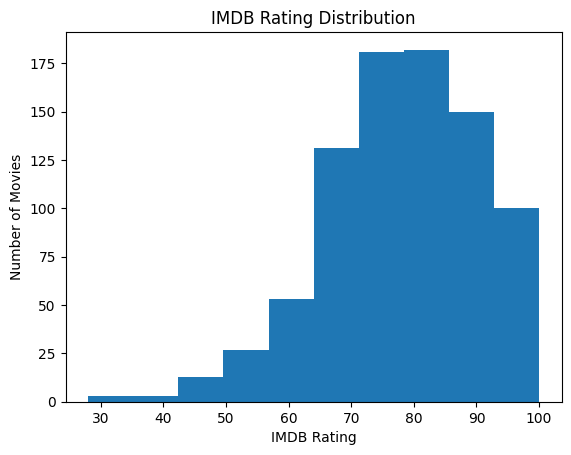

In [17]:
# IMDB Rating Distribution
plt.hist(df['Meta_score'],bins = 10)
plt.title("IMDB Rating Distribution")
plt.xlabel("IMDB Rating")
plt.ylabel("Number of Movies")
plt.show()

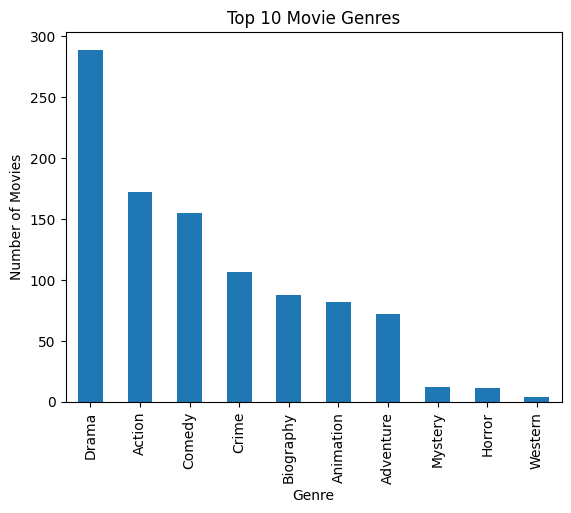

In [18]:
# Top 10 Movie genres
df['Genre'] = df['Genre'].str.split(',').str[0]
genre_counts = df['Genre'].value_counts().head(10)
genre_counts.plot(kind='bar')
plt.title("Top 10 Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.show()

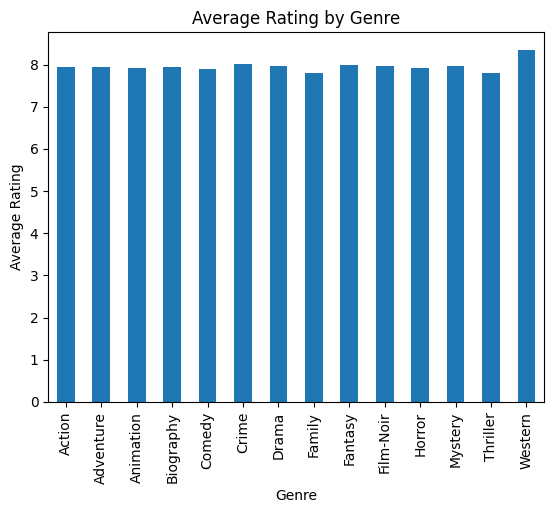

In [19]:
# Average Rating by genre
average_ratings = df.groupby('Genre')['IMDB_Rating'].mean()
average_ratings.plot(kind='bar')
plt.title("Average Rating by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.show()


In [21]:
text = df['Overview'].dropna() # dropna function removes the null values

In [35]:
all_text = " ".join(text)     # storing all overviews together
all_text = all_text.lower()   # Lowercase
print(all_text)

two imprisoned men bond over a number of years, finding solace and eventual redemption through acts of common decency. an organized crime dynasty's aging patriarch transfers control of his clandestine empire to his reluctant son. when the menace known as the joker wreaks havoc and chaos on the people of gotham, batman must accept one of the greatest psychological and physical tests of his ability to fight injustice. the early life and career of vito corleone in 1920s new york city is portrayed, while his son, michael, expands and tightens his grip on the family crime syndicate. a jury holdout attempts to prevent a miscarriage of justice by forcing his colleagues to reconsider the evidence. gandalf and aragorn lead the world of men against sauron's army to draw his gaze from frodo and sam as they approach mount doom with the one ring. the lives of two mob hitmen, a boxer, a gangster and his wife, and a pair of diner bandits intertwine in four tales of violence and redemption. in german-

In [25]:
import re
all_text = re.sub(r"[^a-zA-z0-9\s]","",all_text) # it removes all punctuation marks
print(all_text)

two imprisoned men bond over a number of years finding solace and eventual redemption through acts of common decency an organized crime dynastys aging patriarch transfers control of his clandestine empire to his reluctant son when the menace known as the joker wreaks havoc and chaos on the people of gotham batman must accept one of the greatest psychological and physical tests of his ability to fight injustice the early life and career of vito corleone in 1920s new york city is portrayed while his son michael expands and tightens his grip on the family crime syndicate a jury holdout attempts to prevent a miscarriage of justice by forcing his colleagues to reconsider the evidence gandalf and aragorn lead the world of men against saurons army to draw his gaze from frodo and sam as they approach mount doom with the one ring the lives of two mob hitmen a boxer a gangster and his wife and a pair of diner bandits intertwine in four tales of violence and redemption in germanoccupied poland du

In [26]:
words = all_text.split()

In [31]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [36]:
filtered_words = []                  # remove stopwords
for word in words:
  if word not in stop_words:
    filtered_words.append(word)

In [39]:
from collections import Counter
word_counts = Counter(filtered_words)
top_common_words = word_counts.most_common(10)
print(top_common_words)

[('young', 132), ('man', 109), ('two', 104), ('life', 101), ('world', 78), ('new', 72), ('story', 63), ('war', 61), ('love', 61), ('woman', 60)]
